<a href="https://colab.research.google.com/github/192412588simats-svg/ITA0616/blob/main/exp_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STUDENT STUDY HABITS DATASET
StudyHours Attendance Sleep Result
       Low       Poor   Low   Fail
       Low       Poor  Good   Fail
       Low       Good   Low   Fail
       Low       Good  Good   Pass
    Medium       Poor   Low   Fail
    Medium       Poor  Good   Pass
    Medium       Good   Low   Pass
    Medium       Good  Good   Pass
      High       Poor   Low   Pass
      High       Poor  Good   Pass
      High       Good   Low   Pass
      High       Good  Good   Pass

INITIAL ENTROPY
Pass = 8
Fail = 4
Entropy(S) = 0.9183

INFORMATION GAIN
StudyHours: 0.3774
Attendance: 0.0933
Sleep: 0.0933

ROOT NODE = StudyHours


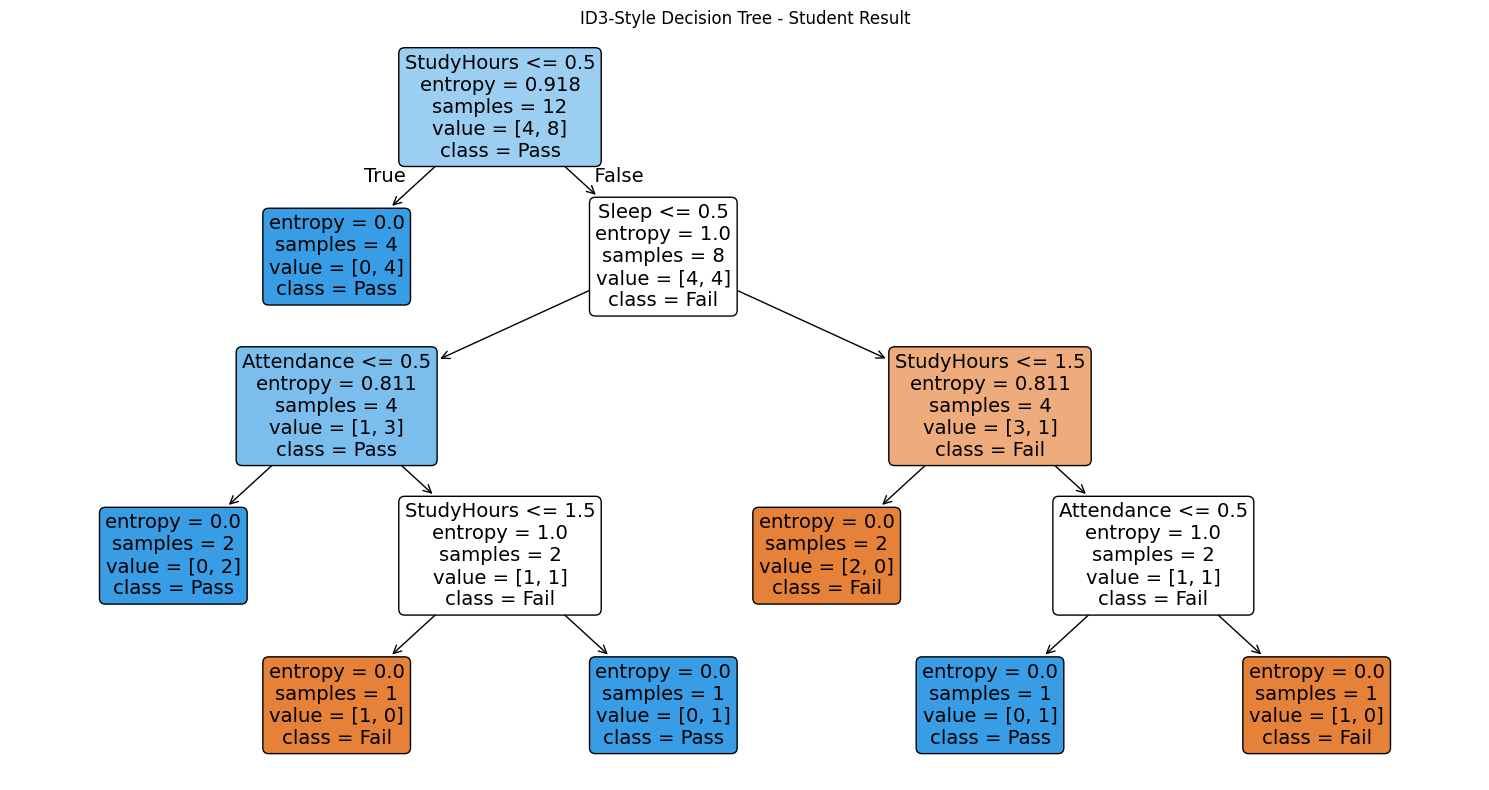


NEW STUDENT
Study Hours = Low
Attendance = Poor
Sleep = Good
Predicted Result = Fail


In [3]:

import pandas as pd
import matplotlib.pyplot as plt
from math import log2
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

# 1. Student Study Habits Dataset
data = {
    'StudyHours': ['Low','Low','Low','Low',
                   'Medium','Medium','Medium','Medium',
                   'High','High','High','High'],
    'Attendance': ['Poor','Poor','Good','Good',
                   'Poor','Poor','Good','Good',
                   'Poor','Poor','Good','Good'],
    'Sleep': ['Low','Good','Low','Good',
              'Low','Good','Low','Good',
              'Low','Good','Low','Good'],
    'Result': ['Fail','Fail','Fail','Pass',
               'Fail','Pass','Pass','Pass',
               'Pass','Pass','Pass','Pass']
}

df = pd.DataFrame(data)

print("STUDENT STUDY HABITS DATASET")
print(df.to_string(index=False))

features = ['StudyHours', 'Attendance', 'Sleep']
target = 'Result'

# 2. Calculate Entropy
def entropy(values):
    counts = values.value_counts()
    total = len(values)
    return -sum((count / total) * log2(count / total)
                for count in counts)

# 3. Calculate Information Gain
def information_gain(df, feature):
    parent_entropy = entropy(df[target])
    weighted_entropy = 0

    for value in df[feature].unique():
        subset = df[df[feature] == value]
        weighted_entropy += (
            len(subset) / len(df)
        ) * entropy(subset[target])

    return parent_entropy - weighted_entropy

print("\nINITIAL ENTROPY")
print("Pass =", (df[target] == 'Pass').sum())
print("Fail =", (df[target] == 'Fail').sum())
print(f"Entropy(S) = {entropy(df[target]):.4f}")

# 4. Information Gain of all attributes
print("\nINFORMATION GAIN")
gains = {}

for feature in features:
    gains[feature] = information_gain(df, feature)
    print(f"{feature}: {gains[feature]:.4f}")

root = max(gains, key=gains.get)
print("\nROOT NODE =", root)

# 5. Encode categorical data
X = df[features].copy()
encoders = {}

for col in features:
    encoders[col] = LabelEncoder()
    X[col] = encoders[col].fit_transform(X[col])

y_encoder = LabelEncoder()
y = y_encoder.fit_transform(df[target])

# 6. Train entropy-based decision tree
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)
model.fit(X, y)

# 7. Display decision tree
plt.figure(figsize=(15, 8))
plot_tree(
    model,
    feature_names=features,
    class_names=list(y_encoder.classes_),
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("ID3-Style Decision Tree - Student Result")
plt.tight_layout()
plt.show()

# 8. Classify a new student
new_student = pd.DataFrame([{
    'StudyHours': 'Low',
    'Attendance': 'Poor',
    'Sleep': 'Good'
}])

for col in features:
    new_student[col] = encoders[col].transform(
        new_student[col]
    )

prediction = model.predict(new_student)
result = y_encoder.inverse_transform(prediction)[0]

print("\nNEW STUDENT")
print("Study Hours = Low")
print("Attendance = Poor")
print("Sleep = Good")
print("Predicted Result =", result)
